In [1]:
## Load libraries
import os
import pandas as pd
import TaxSolver as tx
from TaxSolver.data_wrangling.data_loader import DataLoader
from TaxSolver.data_wrangling.bracket_input import BracketInput
from TaxSolver.constraints.budget_constraint import BudgetConstraint
from TaxSolver.constraints.income_constraint import IncomeConstraint
from TaxSolver.constraints.marginal_pressure_constraint import MarginalPressureConstraint
from TaxSolver.constraints.bracket_constraint import BracketConstraint
from TaxSolver.objective import BudgetObjective
from TaxSolver.backend import GurobiBackend

In [2]:
## Load data
file_path = os.path.join('data', 'simple_simul_1000.xlsx')
df_taxpayers = pd.read_excel(file_path)
df_taxpayers['tax'] = df_taxpayers['income_before_tax'] - df_taxpayers['outcome_1']
df_taxpayers['hh_id'] = df_taxpayers.index

#### Recover

In [3]:
dl = DataLoader(path=df_taxpayers, income_before_tax="income_before_tax", income_after_tax="outcome_1")

tax_solver = tx.TaxSolver(
    dl.households,
    backend=GurobiBackend(),
    )

inflection_points = [0, 25_000, 50_000, 75_000, 100_000, 150_000]

BracketInput.add_split_variables_to_solver(
    tx=tax_solver,
    target_var="income_before_tax",
    inflection_points=inflection_points,
    group_vars=["k_everybody"],
)

income_tax = tx.BracketRule(
    name="income_before_tax_k_everybody",
    var_name="income_before_tax",
    k_group_var="k_everybody",
    ub=1,
    lb=0,
)

tax_solver.add_rules([income_tax])

# Add constraints
income_constraint = IncomeConstraint(0.0000001, dl.households.values())

# No budget bound: the loose cap below is non-binding and only keeps the
# spend variable that defines the revenue-loss objective
budget_constraint = BudgetConstraint(
    "All_households", dl.households.values(), 1_000_000_000
)

tax_solver.add_constraints([income_constraint, budget_constraint])

objective = BudgetObjective(budget_constraint)
tax_solver.add_objective(objective)

tax_solver.solve()

r_and_r = tax_solver.rules_and_rates_table()
r_and_r_recover_c1 = r_and_r.copy()  # consumed by the figure cell
r_and_r

Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Mirror household were missing for 1000 households: set to own id
Set parameter Username


Academic license - for non-commercial use only - expires 2027-07-08


Current tax balance All_households: -19991111
New Maximum: 980008889
Going to solve!
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[arm] - Darwin 24.6.0 24G720)


CPU model: Apple M4 Max


Thread count: 16 physical cores, 16 logical processors, using up to 16 threads


...

Solution count 1: 577.24 


Optimal solution found (tolerance 1.00e-04)


Best objective 5.772398166284e+02, best bound 5.772398166284e+02, gap 0.0000%


Found at least one feasible solution!


,rule_name,rule_type,var_name,rate,b,weight
0,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_0_25000,0.099957,1,1
1,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_25000_50000,0.200023,1,1
2,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_50000_75000,0.300000,1,1
3,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_75000_100000,0.400000,1,1
4,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_100000_150000,0.500000,1,1


#### Case 1, reform 1

In [4]:
dl = DataLoader(path=df_taxpayers, income_before_tax="income_before_tax", income_after_tax="outcome_1")

tax_solver = tx.TaxSolver(
    dl.households,
    backend=GurobiBackend(),)

# Inflection points widened vs. recovery to allow a top-bracket reform
inflection_points = [0, 25_000, 50_000, 75_000, 100_000, 1_000_000]

BracketInput.add_split_variables_to_solver(
    tx=tax_solver,
    target_var="income_before_tax",
    inflection_points=inflection_points,
    group_vars=["k_everybody"],
)

income_tax = tx.BracketRule(
    name="income_before_tax_k_everybody",
    var_name="income_before_tax",
    k_group_var="k_everybody",
    ub=1,
    lb=0,
)

tax_solver.add_rules([income_tax])

# All households: 10% income loss limit
income_constraint = IncomeConstraint(0.10, dl.households.values())

# Household group <70k: must gain at least 5% (new_income >= old_income * 1.05)
low_income_households = [
    hh for hh in dl.households.values() 
    if hh.members[0]["income_before_tax"] < 70_000
]
income_constraint_low_income = IncomeConstraint(-0.05, low_income_households)

# No budget bound: the loose cap below is non-binding and only keeps the
# spend variable that defines the revenue-loss objective
budget_constraint = BudgetConstraint(
    "All_households", dl.households.values(), 1_000_000_000
)

marginal_pressure_constraint = MarginalPressureConstraint(1.0)

tax_solver.add_constraints([
    income_constraint, 
    income_constraint_low_income,
    budget_constraint, 
    marginal_pressure_constraint
])

# Create BracketConstraint for ascending rates
bracket_constraint = BracketConstraint(
    rule_family="income_before_tax_k_everybody",
    max_brackets=None,  # No limit on number of brackets
    ascending=True,     # Rates must be ascending
    start_from_first_inflection=False,
    last_bracket_zero=False,
)
bracket_constraint.brackets = income_tax.flat_rules
tax_solver.add_constraints([bracket_constraint])

objective = BudgetObjective(budget_constraint)
tax_solver.add_objective(objective)

tax_solver.solve()

r_and_r = tax_solver.rules_and_rates_table()
r_and_r_reform1_c1 = r_and_r.copy()  # consumed by the figure cell
r_and_r

Directly loading from pd.DataFrame...
Using 'income_after_tax' as the income before tax column.
Mirror household were missing for 1000 households: set to own id


Current tax balance All_households: -19991111
New Maximum: 980008889
Going to solve!
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[arm] - Darwin 24.6.0 24G720)


CPU model: Apple M4 Max


Thread count: 16 physical cores, 16 logical processors, using up to 16 threads


Optimize a model with 4433 rows, 1013 columns and 6388 nonzeros


...

No other solutions better than -1.47773e+06


Optimal solution found (tolerance 1.00e-04)


Best objective -1.477734059045e+06, best bound -1.477734059045e+06, gap -0.0000%


Found at least one feasible solution!


,rule_name,rule_type,var_name,rate,b,weight
0,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_0_25000,0.054955,1,1
1,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_25000_50000,0.160024,1,1
2,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_50000_75000,0.265000,1,1
3,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_75000_100000,0.640065,1,1
4,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_100000_1000000,0.640065,1,1


## Visualization: Tax System Plots

Plots using consistent RdYlBu colormap styling (blue for data, red for reform).


In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

Y_TITLE = "Taxes paid (€)"
X_TITLE = "Income before tax (€)"
TICK_FONT_SIZE = 14

# Use RdYlBu colormap colors (consistent across all case plots)
cmap = plt.cm.RdYlBu
COLOR_DATA = '#56B4E9'      # Okabe-Ito sky blue: taxpayer data
COLOR_REFORM = '#D55E00'     # Okabe-Ito vermillion: TaxSolver reform

# Jude and Laila colors - yellow for emphasis (matching case_2)
JL_COLOR = '#E69F00'         # Okabe-Ito orange: Jude/Laila highlight
JL_ALPHA = 0.9

def euro_format(x, pos):
    """Format numbers as euro amounts with K for thousands."""
    return f"€{x/1000:.0f}K"

def wrangle_intervals(df_intervals, df_taxpayers):
    """Set max bracket to observed max income."""
    df_intervals = df_intervals.copy()
    df_intervals.iloc[
        df_intervals.index[-1], df_intervals.columns.get_loc("bracket_end")
    ] = df_taxpayers["income_before_tax"].max()
    return df_intervals

def build_tax_line(df_intervals):
    """Build x,y values for a tax line from bracket intervals."""
    x_values = []
    y_values = []
    current_y = 0
    
    for _, row in df_intervals.iterrows():
        x_start, x_end, rate = row["bracket_start"], row["bracket_end"], row["rate"]
        x_interval = [x_start, x_end]
        y_interval = [current_y, current_y + (x_end - x_start) * rate]
        x_values.extend(x_interval)
        y_values.extend(y_interval)
        current_y = y_interval[1]
    
    return x_values, y_values, current_y

# Load taxpayer data (use first 100 for simple visualization)
file_path_plot = os.path.join('data', 'simple_simul_1000.xlsx')
df_taxpayers_plot = pd.read_excel(file_path_plot)
df_taxpayers_plot = df_taxpayers_plot.iloc[0:100, :].copy()
df_taxpayers_plot["tax"] = df_taxpayers_plot["income_before_tax"] - df_taxpayers_plot["outcome_1"]

print(f"Loaded {len(df_taxpayers_plot)} taxpayers for visualization")


Loaded 100 taxpayers for visualization


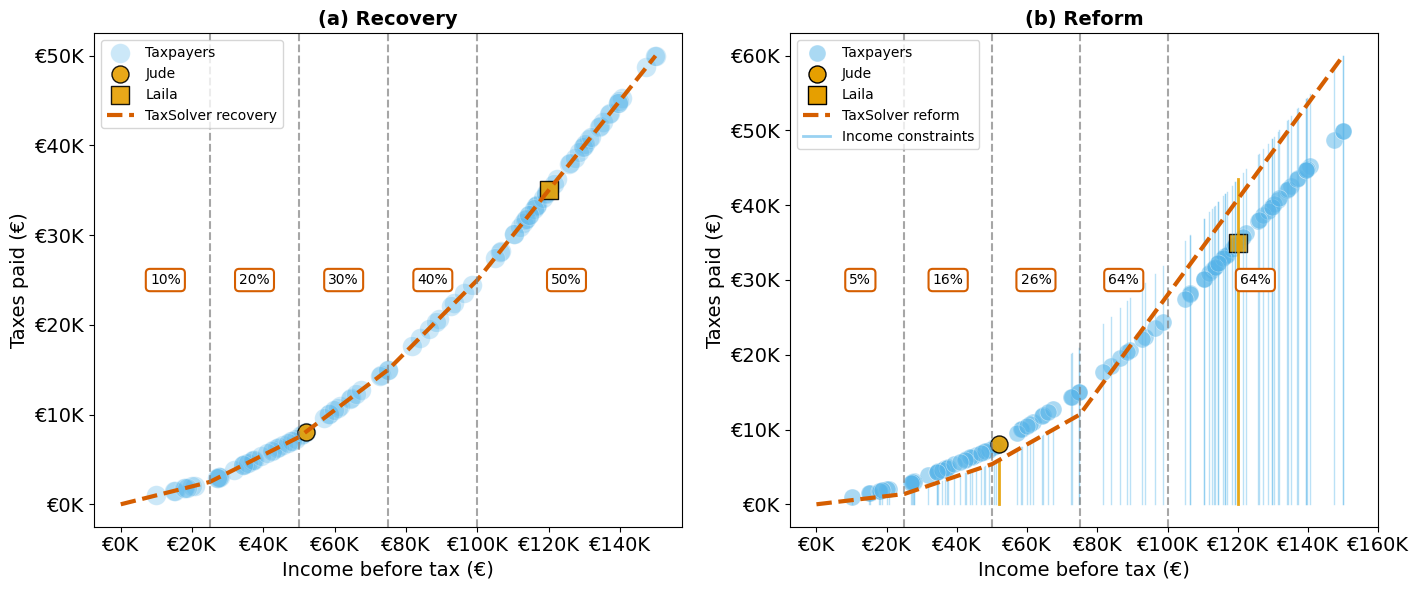

Plot saved to ./output/figs/case_1a_combined.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Calculate income constraint bounds for plot 2
outcome = "outcome_1"
df_taxpayers_plot["tax_ub"] = df_taxpayers_plot.apply(
    lambda row: row["tax"] - 0.05 * row[outcome]
    if row["income_before_tax"] <= 70_000
    else row["tax"] + 0.1 * row[outcome],
    axis=1,
)
df_taxpayers_plot["tax_lb"] = 0

# Intervals come from this notebook's own solves
from case_helpers import rates_to_intervals

df_intervals_recover = rates_to_intervals(r_and_r_recover_c1)
df_intervals_recover = wrangle_intervals(df_intervals_recover, df_taxpayers_plot)
x_recover, y_recover, current_y_recover = build_tax_line(df_intervals_recover)

df_intervals_reform1 = rates_to_intervals(r_and_r_reform1_c1)
df_intervals_reform1 = wrangle_intervals(df_intervals_reform1, df_taxpayers_plot)
x_reform1, y_reform1, current_y_reform1 = build_tax_line(df_intervals_reform1)

# ========== PLOT 1: Recovery ==========
ax1 = axes[0]

ax1.scatter(
    df_taxpayers_plot["income_before_tax"],
    df_taxpayers_plot["tax"],
    color=COLOR_DATA,
    alpha=0.3,
    s=200,
    label="Taxpayers",
    edgecolors='white',
    linewidth=0.5
)

ax1.scatter(df_taxpayers_plot.loc[0, "income_before_tax"], df_taxpayers_plot.loc[0, "tax"],
            color=JL_COLOR, alpha=JL_ALPHA, edgecolor="black", s=150, marker="o")
ax1.scatter(df_taxpayers_plot.loc[1, "income_before_tax"], df_taxpayers_plot.loc[1, "tax"],
            color=JL_COLOR, alpha=JL_ALPHA, edgecolor="black", s=150, marker="s")

ax1.scatter([], [], color=JL_COLOR, alpha=JL_ALPHA, edgecolor="black", s=150, marker="o", label="Jude")
ax1.scatter([], [], color=JL_COLOR, alpha=JL_ALPHA, edgecolor="black", s=150, marker="s", label="Laila")

ax1.plot(x_recover, y_recover, label="TaxSolver recovery", color=COLOR_REFORM, linestyle="--", linewidth=3)

for income in [25_000, 50_000, 75_000, 100_000]:
    ax1.axvline(x=income, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)

for _, row in df_intervals_recover.iterrows():
    x_mid = (row["bracket_start"] + row["bracket_end"]) / 2
    y_mid = current_y_recover / 2
    rate_text = f"{row['rate']:.0%}"
    ax1.text(x_mid, y_mid, rate_text, fontsize=10, color="black",
            ha="center", va="center",
            bbox=dict(facecolor="white", edgecolor=COLOR_REFORM, linestyle="-", linewidth=1.5, boxstyle="round,pad=0.3"))

ax1.set_xlabel(X_TITLE, fontsize=14)
ax1.set_ylabel(Y_TITLE, fontsize=14)
ax1.xaxis.set_major_formatter(FuncFormatter(euro_format))
ax1.yaxis.set_major_formatter(FuncFormatter(euro_format))
ax1.tick_params(axis='both', labelsize=TICK_FONT_SIZE)
ax1.legend(fontsize=10, loc='upper left')
ax1.set_title("(a) Recovery", fontsize=14, fontweight='bold')

# ========== PLOT 2: With Constraints ==========
ax2 = axes[1]

for idx, row in df_taxpayers_plot.iterrows():
    color = JL_COLOR if idx in [0, 1] else COLOR_DATA
    alpha = JL_ALPHA if idx in [0, 1] else 0.4
    lw = 2 if idx in [0, 1] else 1
    ax2.plot([row["income_before_tax"], row["income_before_tax"]], [row["tax_lb"], row["tax_ub"]],
             color=color, alpha=alpha, linewidth=lw)

ax2.scatter(df_taxpayers_plot["income_before_tax"], df_taxpayers_plot["tax"],
            color=COLOR_DATA, alpha=0.5, s=150, label="Taxpayers", edgecolors='white', linewidth=0.5)

ax2.scatter(df_taxpayers_plot.loc[0, "income_before_tax"], df_taxpayers_plot.loc[0, "tax"],
            color=JL_COLOR, alpha=JL_ALPHA, edgecolor="black", s=150, marker="o")
ax2.scatter(df_taxpayers_plot.loc[1, "income_before_tax"], df_taxpayers_plot.loc[1, "tax"],
            color=JL_COLOR, alpha=JL_ALPHA, edgecolor="black", s=150, marker="s")

ax2.scatter([], [], color=JL_COLOR, edgecolor="black", s=150, marker="o", label="Jude")
ax2.scatter([], [], color=JL_COLOR, edgecolor="black", s=150, marker="s", label="Laila")

for income in [25_000, 50_000, 75_000, 100_000]:
    ax2.axvline(x=income, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)

ax2.plot(x_reform1, y_reform1, label="TaxSolver reform", color=COLOR_REFORM, linestyle="--", linewidth=3)

for _, row in df_intervals_reform1.iterrows():
    x_mid = (row["bracket_start"] + row["bracket_end"]) / 2
    y_mid = current_y_reform1 / 2
    rate_text = f"{row['rate']:.0%}"
    ax2.text(x_mid, y_mid, rate_text, fontsize=10, color="black",
            ha="center", va="center",
            bbox=dict(facecolor="white", edgecolor=COLOR_REFORM, linestyle="-", linewidth=1.5, boxstyle="round,pad=0.3"))

ax2.plot([], [], color=COLOR_DATA, linestyle="-", linewidth=2, label="Income constraints", alpha=0.6)

ax2.set_xlabel(X_TITLE, fontsize=14)
ax2.set_ylabel(Y_TITLE, fontsize=14)
ax2.xaxis.set_major_formatter(FuncFormatter(euro_format))
ax2.yaxis.set_major_formatter(FuncFormatter(euro_format))
ax2.tick_params(axis='both', labelsize=TICK_FONT_SIZE)
ax2.set_xlim(right=160_000)
ax2.legend(fontsize=10, loc='upper left')
ax2.set_title("(b) Reform", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('./output/figs/case_1a_combined.png', dpi=900, bbox_inches='tight')
plt.show()

print("Plot saved to ./output/figs/case_1a_combined.png")
